# Step 6 — Capacity Sizing

**目標**：評估系統在 peak / burst 場景下的負載能力。

模擬情境：某一個 loc_2 爆量到現在 peak 的 N 倍，其他 loc_2 維持現在的 peak。

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)
df['hour'] = df['order_created_at'].dt.hour
df['date'] = df['order_created_at'].dt.date
print(f"Loaded {len(df):,} orders")


Loaded 30,000 orders


## 1. Current Capacity: Avg vs Peak

按 loc_2 × hour 計算每小時的 avg / peak 訂單數。

=== Current Capacity by loc_2 ===
  loc_2          Avg/hr  Peak/hr   Peak/Avg    Total
  --------------------------------------------------
  AREA-1           10.1       20        2.0x    7,399
  AREA-2            9.9       20        2.0x    7,277
  AREA-3           10.1       22        2.2x    7,373
  (null)           10.9       21               7,951
  TOTAL            41.0       83


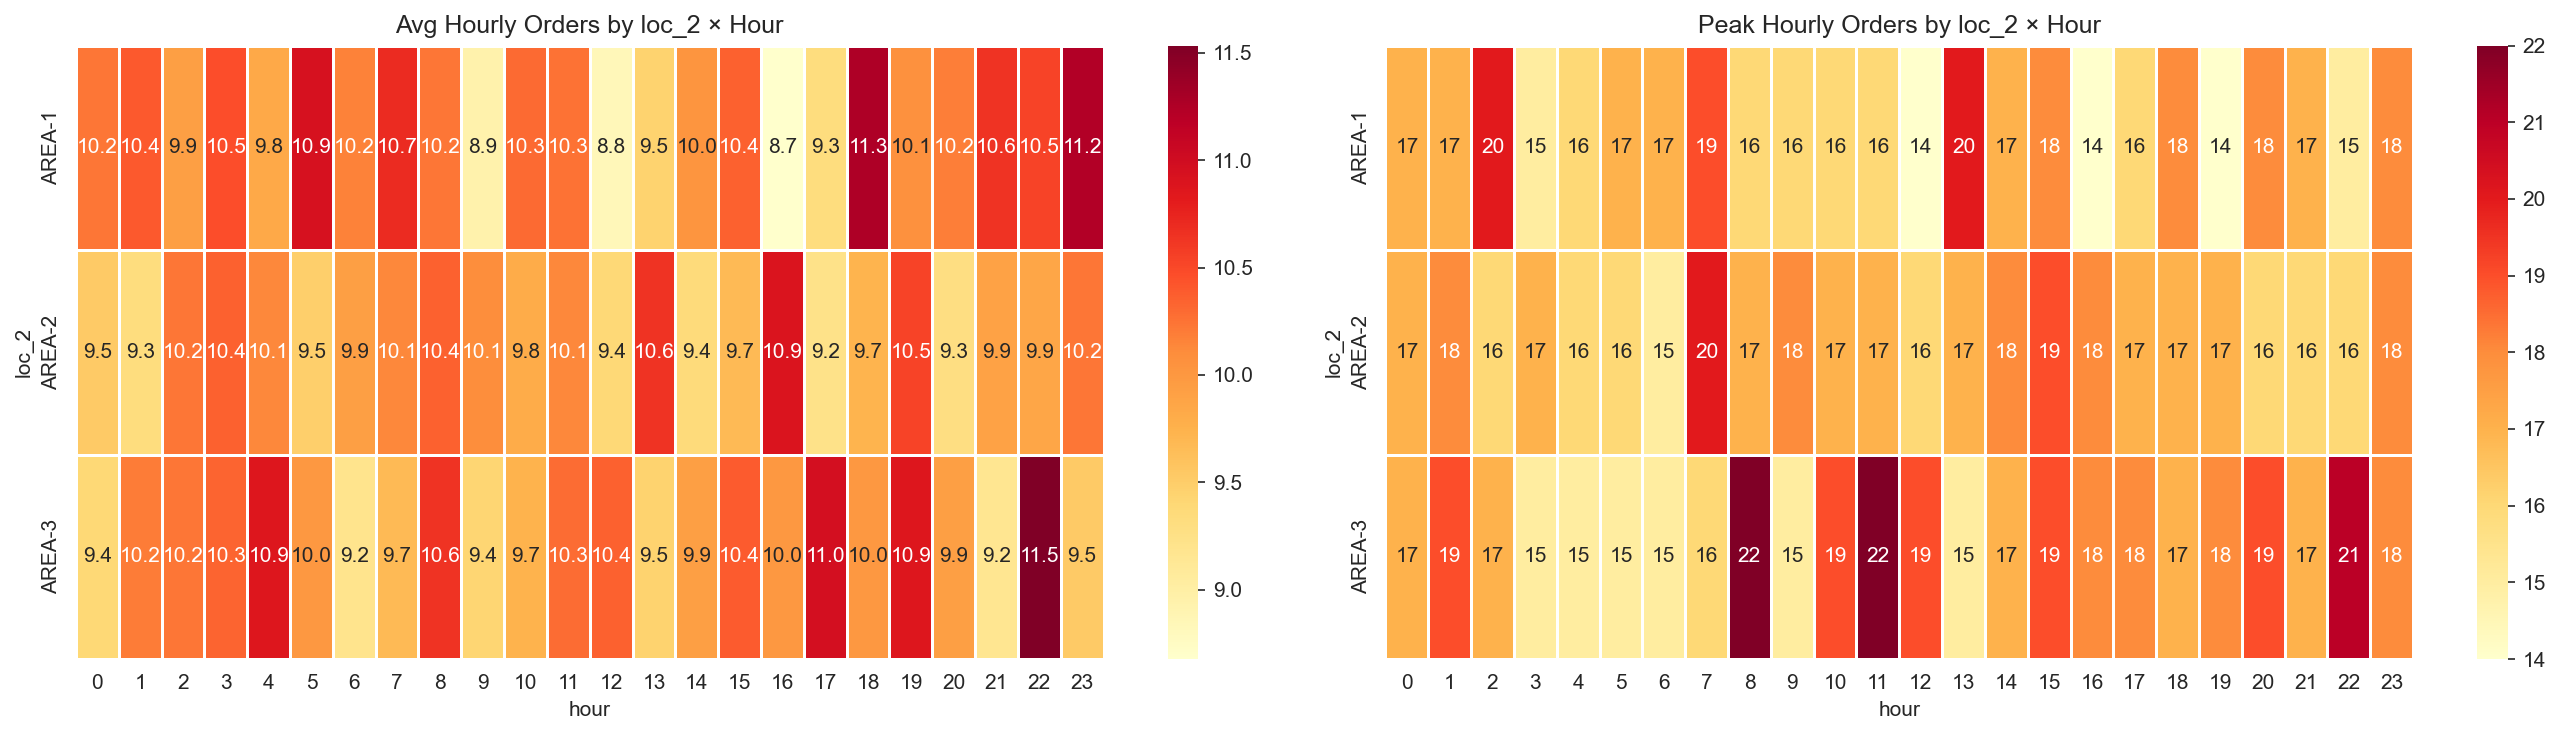

In [3]:
# Hourly order count by loc_2 × date × hour
loc2_data = df.dropna(subset=['loc_2'])
hourly = loc2_data.groupby(['loc_2', 'date', 'hour']).size().reset_index(name='order_count')

# Also track null loc_2 orders
null_data = df[df['loc_2'].isnull()]
null_hourly = null_data.groupby(['date', 'hour']).size().reset_index(name='order_count')
null_avg_hourly = null_hourly['order_count'].mean() if len(null_hourly) > 0 else 0
null_peak_hourly = null_hourly['order_count'].max() if len(null_hourly) > 0 else 0

# Avg and Peak per loc_2 × hour
capacity = hourly.groupby(['loc_2', 'hour']).agg(
    avg=('order_count', 'mean'),
    peak=('order_count', 'max'),
).reset_index()

# Summary table: loc_2 level
loc2_summary = hourly.groupby('loc_2').agg(
    avg_hourly=('order_count', 'mean'),
    peak_hourly=('order_count', 'max'),
    total_orders=('order_count', 'sum'),
).reset_index()
loc2_summary['peak_to_avg'] = (loc2_summary['peak_hourly'] / loc2_summary['avg_hourly']).round(1)

print("=== Current Capacity by loc_2 ===")
print(f"  {'loc_2':<12} {'Avg/hr':>8} {'Peak/hr':>8} {'Peak/Avg':>10} {'Total':>8}")
print("  " + "-" * 50)
for _, row in loc2_summary.iterrows():
    print(f"  {row['loc_2']:<12} {row['avg_hourly']:>8.1f} {row['peak_hourly']:>8.0f} {row['peak_to_avg']:>10.1f}x {row['total_orders']:>8,}")
print(f"  {'(null)':<12} {null_avg_hourly:>8.1f} {null_peak_hourly:>8.0f} {'':>10} {len(null_data):>8,}")
print(f"  {'TOTAL':<12} {loc2_summary['avg_hourly'].sum()+null_avg_hourly:>8.1f} {loc2_summary['peak_hourly'].sum()+null_peak_hourly:>8.0f}")

# Heatmaps: avg vs peak
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

avg_pivot = capacity.pivot_table(index='loc_2', columns='hour', values='avg', fill_value=0)
sns.heatmap(avg_pivot, cmap='YlOrRd', annot=True, fmt='.1f', ax=axes[0], linewidths=0.5)
axes[0].set_title('Avg Hourly Orders by loc_2 × Hour')

peak_pivot = capacity.pivot_table(index='loc_2', columns='hour', values='peak', fill_value=0)
sns.heatmap(peak_pivot, cmap='YlOrRd', annot=True, fmt='.0f', ax=axes[1], linewidths=0.5)
axes[1].set_title('Peak Hourly Orders by loc_2 × Hour')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step6_current_capacity.png', dpi=150, bbox_inches='tight')
plt.show()


## 2. Burst Scenario Simulation

模擬：每個 loc_2 輪流爆量到 peak × `BURST_MULTIPLIER`，
其他 loc_2 維持 current peak。計算全系統 total load。

In [4]:
# Simulate burst scenarios
loc2_list = sorted(loc2_summary['loc_2'].unique())
peak_by_loc2 = loc2_summary.set_index('loc_2')['peak_hourly']

print(f"BURST_MULTIPLIER = {BURST_MULTIPLIER}x")
print(f"null loc_2 peak: {null_peak_hourly:.0f} orders/hr (included in all scenarios)\n")

scenarios = []
for burst_loc in loc2_list:
    burst_load = 0
    others_load = 0
    for loc in loc2_list:
        if loc == burst_loc:
            burst_load = int(peak_by_loc2[loc] * BURST_MULTIPLIER)
        else:
            others_load += int(peak_by_loc2[loc])
    # Add null loc_2 at their peak
    others_load += int(null_peak_hourly)
    total_load = burst_load + others_load
    
    scenarios.append({
        'Burst Location': burst_loc,
        'Burst Load (orders/hr)': burst_load,
        'Other Locs + null Peak (orders/hr)': others_load,
        'Total System Load (orders/hr)': total_load,
    })

scenario_df = pd.DataFrame(scenarios)

# Current baseline (all at peak, including null)
all_peak = int(peak_by_loc2.sum() + null_peak_hourly)
print(f"Current all-peak load: {all_peak} orders/hr (loc_2 peaks + null peak)")
print(f"\n=== Burst Scenarios ===")
print(scenario_df.to_string(index=False))

scenario_df['vs Current Peak'] = (scenario_df['Total System Load (orders/hr)'] / all_peak).round(1).astype(str) + 'x'


BURST_MULTIPLIER = 10x
null loc_2 peak: 21 orders/hr (included in all scenarios)

Current all-peak load: 83 orders/hr (loc_2 peaks + null peak)

=== Burst Scenarios ===
Burst Location  Burst Load (orders/hr)  Other Locs + null Peak (orders/hr)  Total System Load (orders/hr)
        AREA-1                     200                                  63                            263
        AREA-2                     200                                  63                            263
        AREA-3                     220                                  61                            281


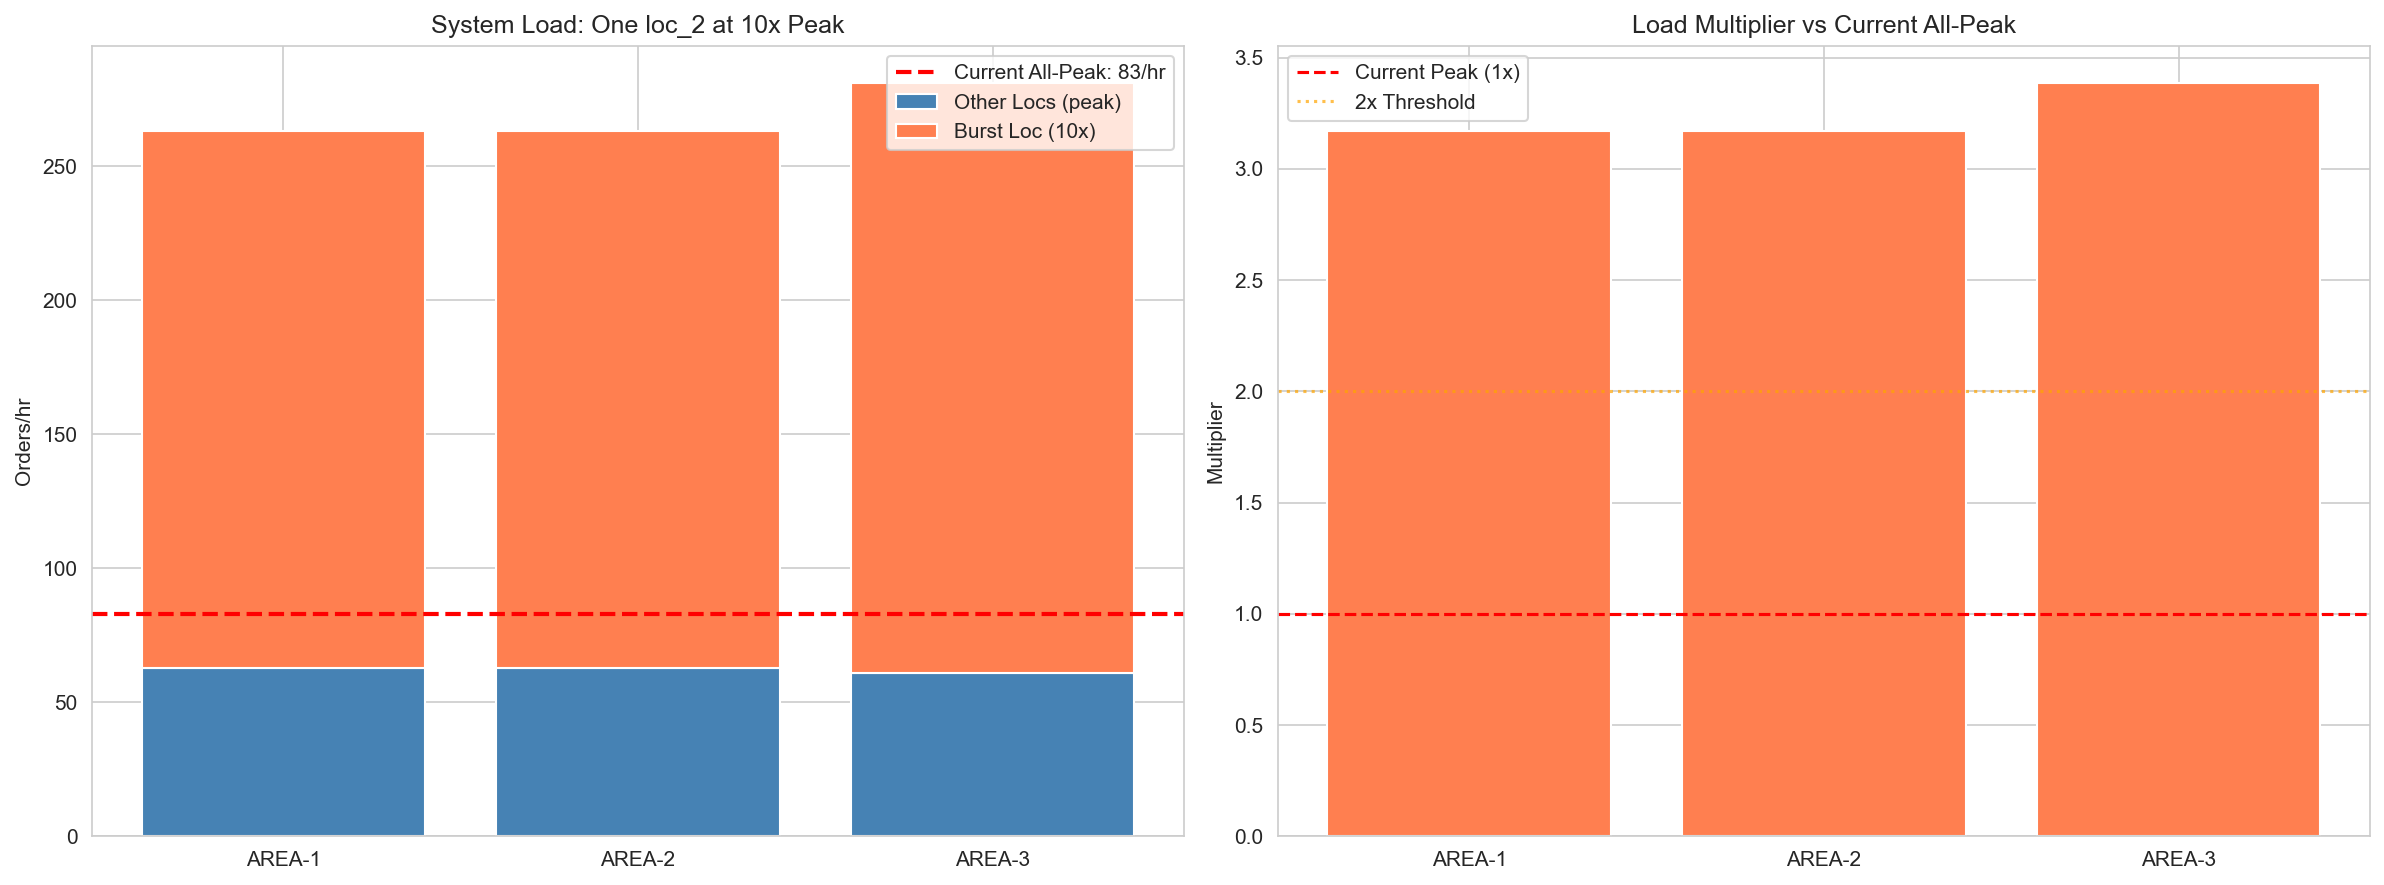

In [5]:
# Visualization: scenario comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart of total load per scenario
ax = axes[0]
x = range(len(scenario_df))
ax.bar(x, scenario_df['Other Locs + null Peak (orders/hr)'], label='Other Locs (peak)', color='steelblue')
ax.bar(x, scenario_df['Burst Load (orders/hr)'], 
       bottom=scenario_df['Other Locs + null Peak (orders/hr)'], label=f'Burst Loc ({BURST_MULTIPLIER}x)', color='coral')
ax.axhline(y=all_peak, color='red', linestyle='--', linewidth=2, label=f'Current All-Peak: {all_peak}/hr')
ax.set_xticks(list(x))
ax.set_xticklabels(scenario_df['Burst Location'])
ax.set_title(f'System Load: One loc_2 at {BURST_MULTIPLIER}x Peak')
ax.set_ylabel('Orders/hr')
ax.legend()

# Right: estimated duration impact
# Use the linear relationship from Step 3 (duration ≈ slope × file_count)
# More orders → more contention → potentially longer device_duration
# But queue is the main concern: more orders per hour → longer queue wait
ax = axes[1]
current_load = all_peak
burst_loads = scenario_df['Total System Load (orders/hr)'].values
multipliers = burst_loads / current_load

ax.bar(range(len(scenario_df)), multipliers, color=['coral' if m > 2 else 'steelblue' for m in multipliers])
ax.axhline(y=1, color='red', linestyle='--', label='Current Peak (1x)')
ax.axhline(y=2, color='orange', linestyle=':', alpha=0.7, label='2x Threshold')
ax.set_xticks(list(range(len(scenario_df))))
ax.set_xticklabels(scenario_df['Burst Location'])
ax.set_title('Load Multiplier vs Current All-Peak')
ax.set_ylabel('Multiplier')
ax.legend()

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step6_burst_scenarios.png', dpi=150)
plt.show()


## 3. Hourly Capacity Timeline

每小時的實際訂單量 vs burst 情境下的預估量。

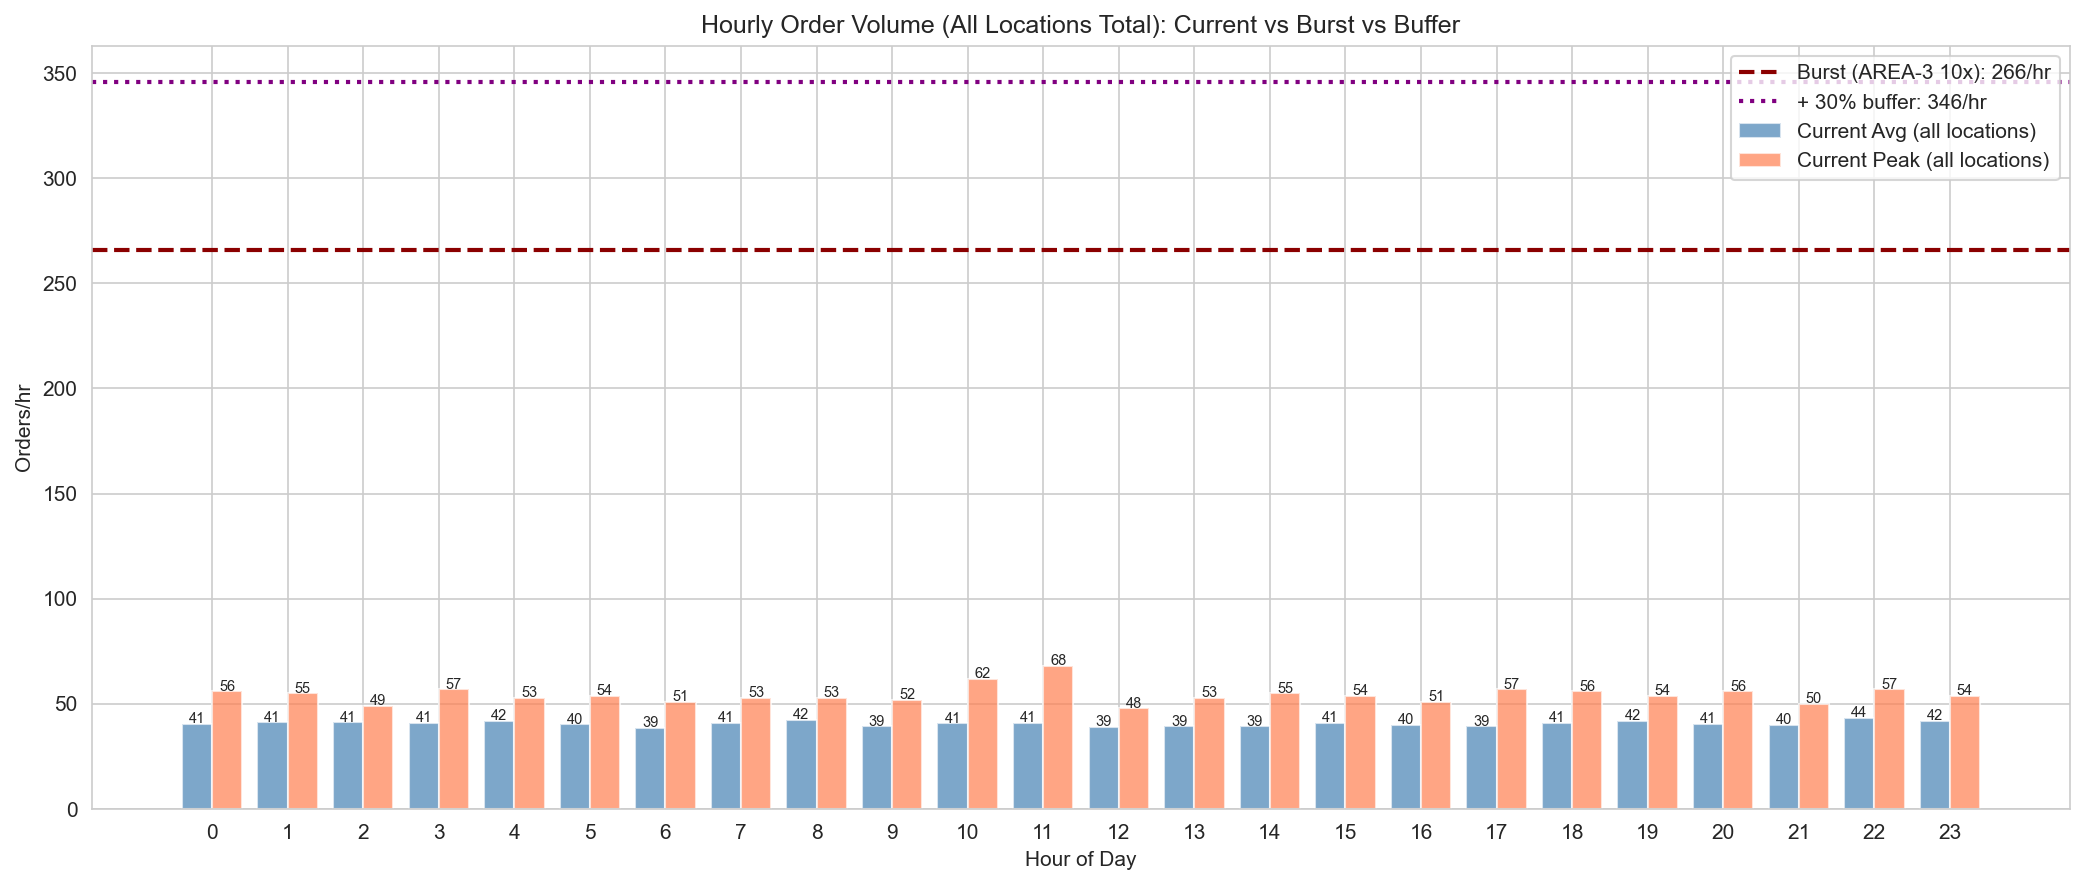

Current peak hour: 11:00 (68 orders)
Burst scenario (AREA-3 10x): 266 orders/hr
+ 30% buffer: 346 orders/hr


In [6]:
# Hourly timeline: current vs burst vs buffered
total_hourly = df.groupby(['date', 'hour']).size().reset_index(name='order_count')
hourly_stats = total_hourly.groupby('hour').agg(
    avg=('order_count', 'mean'),
    peak=('order_count', 'max'),
).reset_index()

busiest_loc = peak_by_loc2.idxmax()
busiest_peak = peak_by_loc2.max()
burst_delta = busiest_peak * (BURST_MULTIPLIER - 1)

fig, ax = plt.subplots(figsize=(14, 6))
bars_avg = ax.bar(hourly_stats['hour'] - 0.2, hourly_stats['avg'], width=0.4, 
                   label='Current Avg (all locations)', color='steelblue', alpha=0.7)
bars_peak = ax.bar(hourly_stats['hour'] + 0.2, hourly_stats['peak'], width=0.4, 
                    label='Current Peak (all locations)', color='coral', alpha=0.7)

# Number labels on bars
for bar in bars_avg:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.0f}', ha='center', fontsize=7)
for bar in bars_peak:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.3, f'{h:.0f}', ha='center', fontsize=7)

# Burst line
burst_level = hourly_stats['peak'].max() + burst_delta
ax.axhline(y=burst_level, color='darkred', linestyle='--', linewidth=2,
           label=f'Burst ({busiest_loc} {BURST_MULTIPLIER}x): {burst_level:.0f}/hr')

# Buffer line
buffered_level = burst_level * CAPACITY_BUFFER
ax.axhline(y=buffered_level, color='purple', linestyle=':', linewidth=2,
           label=f'+ {(CAPACITY_BUFFER-1)*100:.0f}% buffer: {buffered_level:.0f}/hr')

ax.set_title('Hourly Order Volume (All Locations Total): Current vs Burst vs Buffer')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Orders/hr')
ax.set_xticks(range(24))
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step6_hourly_capacity.png', dpi=150)
plt.show()

print(f"Current peak hour: {hourly_stats.loc[hourly_stats['peak'].idxmax(), 'hour']:.0f}:00 ({hourly_stats['peak'].max():.0f} orders)")
print(f"Burst scenario ({busiest_loc} {BURST_MULTIPLIER}x): {burst_level:.0f} orders/hr")
print(f"+ {(CAPACITY_BUFFER-1)*100:.0f}% buffer: {buffered_level:.0f} orders/hr")


## 4. Concurrency Estimation (Little's Law)

Orders/hr 不能直接當 concurrency。
同時在處理的訂單數 = **到達率 × 平均處理時間**

Processing time (total_duration_seconds, normal orders):
  avg=261s (4.3min), P50=82s, P95=973s

=== Order Concurrency (Little's Law: L = λ × W) ===
Scenario                   Orders/hr   Conc (avg)   Conc (P95)
--------------------------------------------------------------
Current Avg                       41          3.0         11.0
Current Peak                      68          4.9         18.4
Burst (10x)                      281         20.4         75.9
Burst + 30% buffer               365         26.5         98.7

  Conc = 同時在處理的訂單數 = Orders/hr × Processing Time / 3600
  avg dur: 用正常訂單平均耗時 (261s) 估算
  P95 dur: 用正常訂單 P95 耗時 (973s) 估算（悲觀情境）


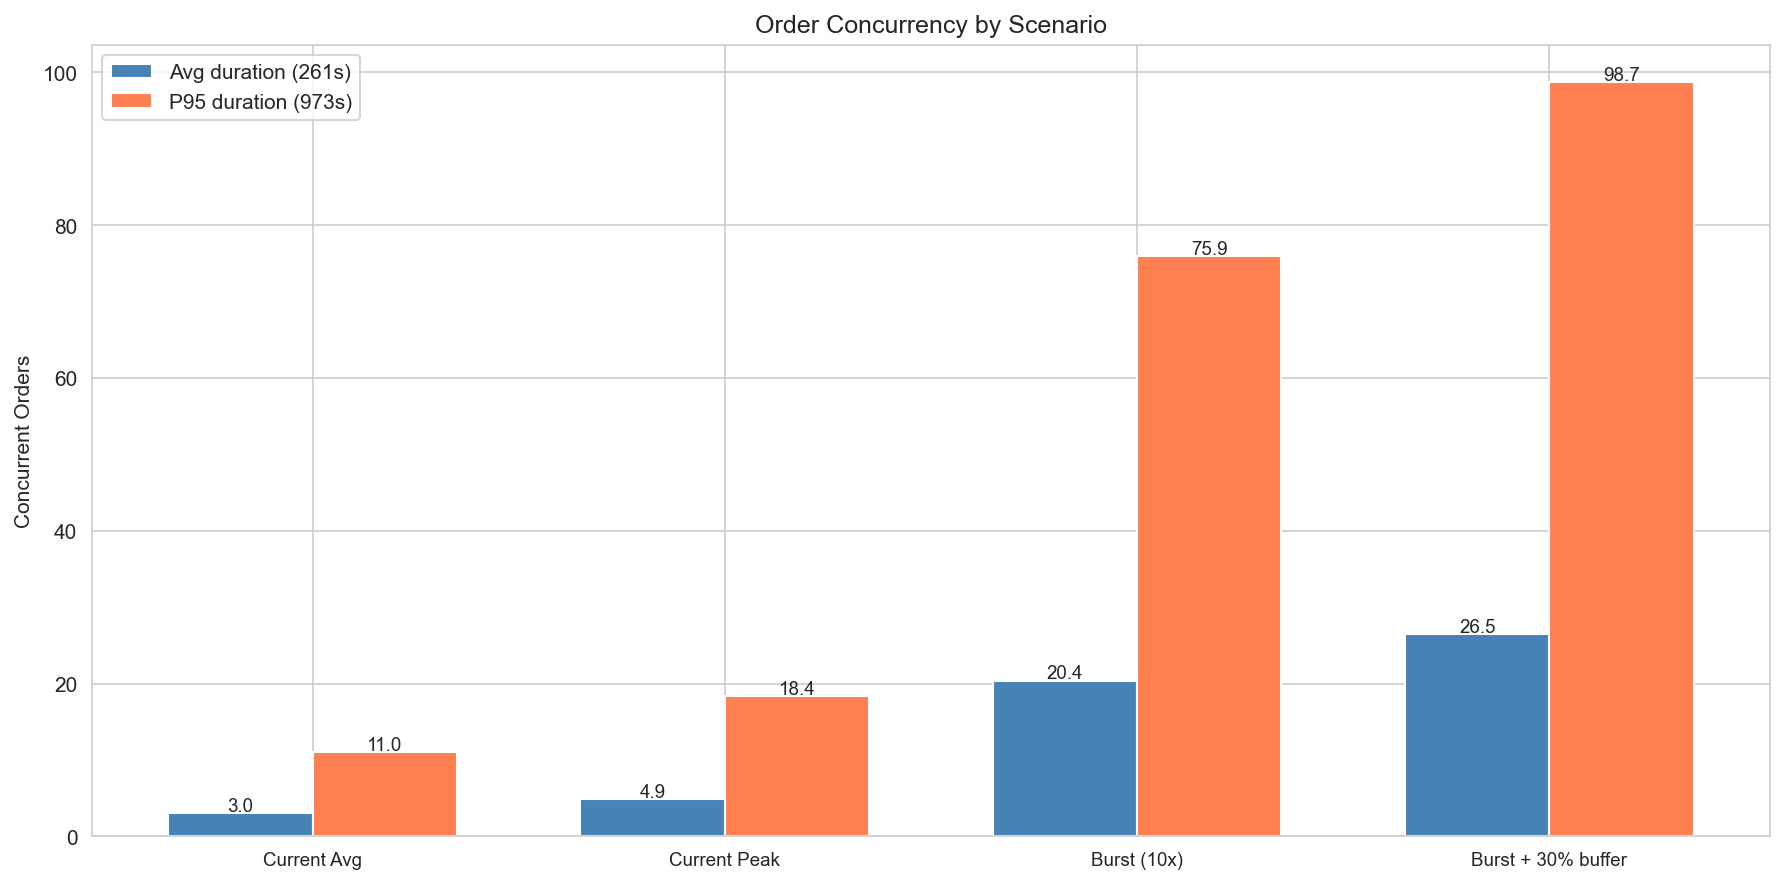

In [7]:
# Concurrency estimation using Little's Law
# L = λ × W  (concurrent orders = arrival_rate × avg_processing_time)

# Normal orders only (exclude anomalies for realistic duration estimate)
sys_flags = pd.read_csv('../data/system_anomaly_flags.csv')
usr_flags = pd.read_csv('../data/user_anomaly_flags.csv')
merged = df.merge(sys_flags[['order_id', 'is_system_anomaly']], on='order_id').merge(usr_flags, on='order_id')
normal = merged[~(merged['is_system_anomaly'] | merged['is_user_anomaly'])]

avg_duration_sec = normal['total_duration_seconds'].mean()
p50_duration_sec = normal['total_duration_seconds'].median()
p95_duration_sec = normal['total_duration_seconds'].quantile(0.95)

print(f"Processing time (total_duration_seconds, normal orders):")
print(f"  avg={avg_duration_sec:.0f}s ({avg_duration_sec/60:.1f}min), P50={p50_duration_sec:.0f}s, P95={p95_duration_sec:.0f}s")

# Build concurrency table
scenarios_conc = []
scenarios_conc.append({'Scenario': 'Current Avg', 'Orders/hr': hourly_stats['avg'].mean()})
scenarios_conc.append({'Scenario': 'Current Peak', 'Orders/hr': hourly_stats['peak'].max()})
max_burst = scenario_df['Total System Load (orders/hr)'].max()
scenarios_conc.append({'Scenario': f'Burst ({BURST_MULTIPLIER}x)', 'Orders/hr': max_burst})
scenarios_conc.append({'Scenario': f'Burst + {(CAPACITY_BUFFER-1)*100:.0f}% buffer', 'Orders/hr': max_burst * CAPACITY_BUFFER})

conc_df = pd.DataFrame(scenarios_conc)
conc_df['Conc (avg dur)'] = (conc_df['Orders/hr'] * avg_duration_sec / 3600).round(1)
conc_df['Conc (P95 dur)'] = (conc_df['Orders/hr'] * p95_duration_sec / 3600).round(1)

print(f"\n=== Order Concurrency (Little's Law: L = λ × W) ===")
print(f"{'Scenario':<25} {'Orders/hr':>10} {'Conc (avg)':>12} {'Conc (P95)':>12}")
print("-" * 62)
for _, row in conc_df.iterrows():
    print(f"{row['Scenario']:<25} {row['Orders/hr']:>10.0f} {row['Conc (avg dur)']:>12.1f} {row['Conc (P95 dur)']:>12.1f}")

print(f"\n  Conc = 同時在處理的訂單數 = Orders/hr × Processing Time / 3600")
print(f"  avg dur: 用正常訂單平均耗時 ({avg_duration_sec:.0f}s) 估算")
print(f"  P95 dur: 用正常訂單 P95 耗時 ({p95_duration_sec:.0f}s) 估算（悲觀情境）")

# Chart
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(conc_df))
w = 0.35
bars1 = ax.bar([i - w/2 for i in x], conc_df['Conc (avg dur)'], width=w,
               label=f'Avg duration ({avg_duration_sec:.0f}s)', color='steelblue')
bars2 = ax.bar([i + w/2 for i in x], conc_df['Conc (P95 dur)'], width=w,
               label=f'P95 duration ({p95_duration_sec:.0f}s)', color='coral')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{bar.get_height():.1f}', ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(conc_df['Scenario'], fontsize=9)
ax.set_title('Order Concurrency by Scenario')
ax.set_ylabel('Concurrent Orders')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'step6_concurrency.png', dpi=150)
plt.show()


## 5. Capacity Recommendation

用哪個 concurrency 數字來決定 CPU/Memory？

In [8]:
# Capacity recommendation
avg_conc_burst = conc_df[conc_df['Scenario'].str.contains('buffer')]['Conc (avg dur)'].values[0]
p95_conc_burst = conc_df[conc_df['Scenario'].str.contains('buffer')]['Conc (P95 dur)'].values[0]

print("=" * 60)
print("Capacity Recommendation")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────────┐
│  選擇           │ Concurrent Orders │  適合場景         │
├─────────────────┼───────────────────┼───────────────────┤
│  Avg duration   │ {avg_conc_burst:>12.1f}      │  有 autoscaling   │
│  P95 duration   │ {p95_conc_burst:>12.1f}      │  固定資源（推薦） │
└─────────────────┴───────────────────┴───────────────────┘

推薦：用 P95 duration 的 burst + buffer = {p95_conc_burst:.0f} concurrent orders

原因：
  - Burst scenario ({BURST_MULTIPLIER}x) = 流量最壞情境
  - P95 duration ({p95_duration_sec:.0f}s) = 處理時間最壞情境
  - 兩者疊加 → 幾乎不會被打爆
  - 實際日常只有 {conc_df.iloc[0]['Conc (avg dur)']:.1f} concurrent orders，資源大量閒置但安全

如果 {p95_conc_burst:.0f} 太多：
  - 退一步用 avg duration = {avg_conc_burst:.1f} concurrent orders
  - 搭配 autoscaling 應對 tail orders
""")


Capacity Recommendation

┌─────────────────────────────────────────────────────────┐
│  選擇           │ Concurrent Orders │  適合場景         │
├─────────────────┼───────────────────┼───────────────────┤
│  Avg duration   │         26.5      │  有 autoscaling   │
│  P95 duration   │         98.7      │  固定資源（推薦） │
└─────────────────┴───────────────────┴───────────────────┘

推薦：用 P95 duration 的 burst + buffer = 99 concurrent orders

原因：
  - Burst scenario (10x) = 流量最壞情境
  - P95 duration (973s) = 處理時間最壞情境
  - 兩者疊加 → 幾乎不會被打爆
  - 實際日常只有 3.0 concurrent orders，資源大量閒置但安全

如果 99 太多：
  - 退一步用 avg duration = 26.5 concurrent orders
  - 搭配 autoscaling 應對 tail orders



## 6. Summary

In [9]:
# Export summary
summary = []
summary.append("=" * 60)
summary.append("Step 6 — Capacity Sizing")
summary.append("=" * 60)

summary.append(f"\nBURST_MULTIPLIER = {BURST_MULTIPLIER}x")
summary.append(f"CAPACITY_BUFFER = {CAPACITY_BUFFER}x ({(CAPACITY_BUFFER-1)*100:.0f}% buffer)")

summary.append(f"\n--- 計算邏輯 ---")
summary.append(f"  Peak = burst_loc's peak × {BURST_MULTIPLIER} + 其他 loc_2's current peak")
summary.append(f"  Capacity = Peak × {CAPACITY_BUFFER} (buffer)")

summary.append(f"\n--- Current Capacity ---")
summary.append(f"  All-peak: {all_peak} orders/hr (含 null loc_2)")
for _, row in loc2_summary.iterrows():
    summary.append(f"  {row['loc_2']}: avg={row['avg_hourly']:.1f}/hr, peak={row['peak_hourly']:.0f}/hr")
summary.append(f"  (null): avg={null_avg_hourly:.1f}/hr, peak={null_peak_hourly:.0f}/hr")

summary.append(f"\n--- Burst Scenarios ---")
for _, row in scenario_df.iterrows():
    total = row['Total System Load (orders/hr)']
    buffered = int(total * CAPACITY_BUFFER)
    summary.append(f"  {row['Burst Location']} burst: {row['Burst Load (orders/hr)']} + {row['Other Locs + null Peak (orders/hr)']} = {total}/hr → ×{CAPACITY_BUFFER} = {buffered}/hr")

max_burst = scenario_df['Total System Load (orders/hr)'].max()
max_buffered = int(max_burst * CAPACITY_BUFFER)
summary.append(f"\n--- Capacity Planning ---")
summary.append(f"  Worst-case: {max_buffered} orders/hr ({BURST_MULTIPLIER}x burst + {(CAPACITY_BUFFER-1)*100:.0f}% buffer)")

summary.append(f"\n--- Concurrency (Little's Law) ---")
summary.append(f"  公式: 同時處理的訂單數 = 到達率(orders/hr) × 每筆處理時間(s) ÷ 3600")
summary.append(f"")
summary.append(f"  正常訂單平均處理時間: {avg_duration_sec:.0f}s ({avg_duration_sec/60:.1f}min)")
summary.append(f"  正常訂單 P95 處理時間: {p95_duration_sec:.0f}s ({p95_duration_sec/60:.1f}min)  ← 慢訂單")
summary.append(f"")
summary.append(f"  {'Scenario':<25} {'Orders/hr':>10} {'× avg dur':>10} {'× P95 dur':>10}")
summary.append(f"  {'-'*58}")
for _, row in conc_df.iterrows():
    summary.append(f"  {row['Scenario']:<25} {row['Orders/hr']:>10.0f} {row['Conc (avg dur)']:>8.1f} 筆 {row['Conc (P95 dur)']:>8.1f} 筆")
summary.append(f"")
summary.append(f"  × avg dur = 大部分訂單正常時的同時處理數")
summary.append(f"  × P95 dur = 如果同時在跑的訂單大多是慢的（悲觀估計）")

summary.append(f"\n--- Capacity Recommendation ---")
summary.append(f"  Avg duration scenario: {avg_conc_burst:.1f} concurrent orders  （有 autoscaling 時用）")
summary.append(f"  P95 duration scenario: {p95_conc_burst:.1f} concurrent orders  （固定資源，推薦）")
summary.append(f"  推薦用 P95 = {p95_conc_burst:.0f} concurrent orders 來決定 CPU/Memory")
summary.append(f"  日常實際: ~{conc_df.iloc[0]['Conc (avg dur)']:.1f} concurrent orders")

with open(str(REPORTS_DIR / 'step6_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step6_summary.txt")
print('\n'.join(summary))


Saved: reports/step6_summary.txt
Step 6 — Capacity Sizing

BURST_MULTIPLIER = 10x
CAPACITY_BUFFER = 1.3x (30% buffer)

--- 計算邏輯 ---
  Peak = burst_loc's peak × 10 + 其他 loc_2's current peak
  Capacity = Peak × 1.3 (buffer)

--- Current Capacity ---
  All-peak: 83 orders/hr (含 null loc_2)
  AREA-1: avg=10.1/hr, peak=20/hr
  AREA-2: avg=9.9/hr, peak=20/hr
  AREA-3: avg=10.1/hr, peak=22/hr
  (null): avg=10.9/hr, peak=21/hr

--- Burst Scenarios ---
  AREA-1 burst: 200 + 63 = 263/hr → ×1.3 = 341/hr
  AREA-2 burst: 200 + 63 = 263/hr → ×1.3 = 341/hr
  AREA-3 burst: 220 + 61 = 281/hr → ×1.3 = 365/hr

--- Capacity Planning ---
  Worst-case: 365 orders/hr (10x burst + 30% buffer)

--- Concurrency (Little's Law) ---
  公式: 同時處理的訂單數 = 到達率(orders/hr) × 每筆處理時間(s) ÷ 3600

  正常訂單平均處理時間: 261s (4.3min)
  正常訂單 P95 處理時間: 973s (16.2min)  ← 慢訂單

  Scenario                   Orders/hr  × avg dur  × P95 dur
  ----------------------------------------------------------
  Current Avg                       41      